# CRR（Crown–Root Ratio）演算法

依據 `algo.md` 實作：mask → PCA 長軸 → 三種 CEJ 訊號（寬度輪廓／灰階轉換／輪廓曲率）→ Top-K 左右候選配對 → CEJ 線與長軸交點 → CRR。

**流程**

1. 前處理（percentile normalization、CLAHE）與 mask 後處理（最大連通區、填洞、opening/closing、邊界檢查）
2. PCA 長軸 `L`：方向統一為「牙冠 → 牙根」（t 遞增），端點 `A`、`B` 取投影值 1% / 99% 百分位
3. 左右 CEJ 候選：沿長軸切 bin，計算 width profile、gray transition、contour curvature 三種分數
4. 對 `(Li, Rj)` 計算 pair score（所有權重集中在 `CFG`），取最高分為 `C`、`D`
5. `O = L ∩ CD`，`CRR = |A−O| / |O−B|`；另提供 `bilateral_midpoint` 模式
6. 評估函式（CEJ 點誤差、CEJ 線角度、CRR MAE/RMSE/MAPE/Pearson/Bland–Altman）、合成 mask 驗證、真實影像測試

**限制**：mask 來源為未校正的 SAM pseudo-label；權重/閾值為初始值，需用醫師標註的 CEJ 調整。輸出為 CEJ *candidate*，不是臨床診斷。

In [42]:
from __future__ import annotations

import json
from dataclasses import dataclass, field, asdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
SEED = 0
np.random.seed(SEED)

PROJECT_ROOT = next(
    (d for d in (Path.cwd(), *Path.cwd().parents)
     if (d / "reports/models/sam_pseudo_labels/coco_annotations.json").exists()
     and (d / "data/processed").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("找不到專案資料；請從 tooth_ratio 專案內啟動 notebook。")
OUTPUT_DIR = PROJECT_ROOT / "reports/models/crr_algo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 所有權重與閾值集中於此（對應 algo.md 的 default.yaml）。長度類參數以「軸長比例」表示，避免固定像素。
CFG = {
    "preprocess": {"p_low": 1.0, "p_high": 99.0, "clahe": True, "clahe_clip": 2.0, "clahe_grid": 8,
                   "gauss_sigma": 0.8},
    "mask": {"open_r": 1, "close_r": 2, "border_margin_px": 2},
    "axis": {"endpoint_percentile": 1.0, "end_segment_frac": 0.25, "orientation_ambiguity": 0.85},
    "profile": {"n_bins": 120, "smooth_sigma_bins": 2.0,
                "gray_sigmas_bins": [1.5, 3.0, 5.0], "gray_inset_frac": 0.04, "gray_depth_frac": 0.12,
                "gray_samples": 5, "curv_sigma_fracs": [0.01, 0.02, 0.04]},
    "candidates": {"top_k": 5, "t_range": [0.15, 0.85], "min_sep_frac": 0.05,
                   "side_weights": {"width": 0.4, "gray": 0.3, "curvature": 0.3},
                   "max_contour_dist_px": 3.0, "image_border_margin_px": 3},
    "pair_weights": {"width": 0.20, "gray": 0.15, "curvature": 0.15, "level": 0.20,
                     "symmetry": 0.10, "angle": 0.10, "anatomy": 0.10},
    "constraints": {"max_level_diff_frac": 0.20, "min_line_axis_angle_deg": 25.0},
    "scoring": {"level_sigma_frac": 0.08, "anatomy_center": 0.40, "anatomy_sigma": 0.15},
    "geometry": {"cej_reference": "axis_intersection",  # 或 "bilateral_midpoint"
                 "min_root_length_frac": 0.05, "crr_plausible": [0.1, 3.0]},
    "confidence": {"warning_penalty": 0.75},
}

## 1. 資料結構

In [43]:
@dataclass
class Point:
    x: float
    y: float

    def arr(self) -> np.ndarray:
        return np.array([self.x, self.y], dtype=np.float64)


def _pt(a) -> Point:
    return Point(float(a[0]), float(a[1]))


@dataclass
class CRRResult:
    left_cej: Point
    right_cej: Point
    cej_midpoint: Point
    crown_endpoint: Point
    root_endpoint: Point
    tooth_axis_start: Point
    tooth_axis_end: Point
    crown_length_px: float
    root_length_px: float
    crr: float
    cej_pair_score: float
    confidence: float
    warnings: list[str] = field(default_factory=list)
    crr_bilateral_midpoint: float = float("nan")
    crown_length_mm: float | None = None
    root_length_mm: float | None = None


@dataclass
class ToothAxis:
    """長軸座標系：t 沿長軸（牙冠 → 牙根遞增），s 為垂直方向，n = (v_y, -v_x)。"""
    center: np.ndarray
    v: np.ndarray
    n: np.ndarray
    t_lo: float
    t_hi: float
    warnings: list[str] = field(default_factory=list)

    @property
    def extent(self) -> float:
        return self.t_hi - self.t_lo

    def point(self, t: float, s: float = 0.0) -> np.ndarray:
        return self.center + self.v * t + self.n * s

    def coords(self, xy: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        d = np.asarray(xy, dtype=np.float64) - self.center
        return d @ self.v, d @ self.n


@dataclass
class Candidate:
    side: str            # "left"（s<0）或 "right"（s>0）
    bin: int
    t: float
    xy: np.ndarray
    half_width: float
    width: float
    gray: float
    curvature: float
    total: float

## 2. 前處理與 mask 後處理

In [44]:
def to_gray(image: np.ndarray) -> np.ndarray:
    """RGB/灰階 → 單通道 float32。"""
    img = np.asarray(image)
    if img.ndim == 3:
        img = cv2.cvtColor(img.astype(np.uint8) if img.dtype != np.uint8 else img, cv2.COLOR_RGB2GRAY)
    if img.ndim != 2:
        raise ValueError(f"影像維度錯誤：{img.shape}")
    return img.astype(np.float32)


def preprocess(image: np.ndarray, cfg: dict) -> np.ndarray:
    """percentile normalization → 可選 CLAHE → 輕度 Gaussian（避免抹掉 CEJ 灰階變化）。回傳 [0,1] float32。"""
    p = cfg["preprocess"]
    g = to_gray(image)
    lo, hi = np.percentile(g, [p["p_low"], p["p_high"]])
    if hi - lo < 1e-6:
        raise ValueError("影像對比為零，無法正規化。")
    g = np.clip((g - lo) / (hi - lo), 0, 1)
    if p["clahe"]:
        clahe = cv2.createCLAHE(clipLimit=p["clahe_clip"], tileGridSize=(p["clahe_grid"],) * 2)
        g = clahe.apply((g * 255).astype(np.uint8)).astype(np.float32) / 255.0
    if p["gauss_sigma"] > 0:
        g = cv2.GaussianBlur(g, (0, 0), p["gauss_sigma"])
    return g


def clean_mask(mask: np.ndarray, cfg: dict) -> tuple[np.ndarray, dict]:
    """最大連通區 → 填洞 → opening/closing；回傳 (mask, flags)。"""
    m = (np.asarray(mask) > 0).astype(np.uint8)
    flags = {"empty": False, "touches_border": [], "n_components": 0}
    if m.sum() == 0:
        flags["empty"] = True
        return m.astype(bool), flags
    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    flags["n_components"] = n - 1
    m = (labels == 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))).astype(np.uint8)
    h, w = m.shape
    inv = (1 - m).astype(np.uint8)
    ff = np.zeros((h + 2, w + 2), np.uint8)
    if inv[0, 0] == 1:
        cv2.floodFill(inv, ff, (0, 0), 2)  # 背景標記，剩下的 1 即內部孔洞
    m[inv == 1] = 1
    for r, op in ((cfg["mask"]["open_r"], cv2.MORPH_OPEN), (cfg["mask"]["close_r"], cv2.MORPH_CLOSE)):
        if r > 0:
            k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
            m = cv2.morphologyEx(m, op, k)
    mg = cfg["mask"]["border_margin_px"]
    ys, xs = np.nonzero(m)
    if len(xs):
        for name, hit in (("left", xs.min() < mg), ("right", xs.max() >= w - mg),
                          ("top", ys.min() < mg), ("bottom", ys.max() >= h - mg)):
            if hit:
                flags["touches_border"].append(name)
    flags["empty"] = m.sum() == 0
    return m.astype(bool), flags

## 3. PCA 長軸與端點 A、B

PCA 第一主成分為長軸 `v`，mask 質心為基準點。PCA 的正負號不固定，因此以「牙根端較窄」判斷牙冠→牙根方向（t 遞增朝牙根）；兩端寬度太接近時輸出 warning，不靜默使用。

In [45]:
def tooth_axis(mask: np.ndarray, cfg: dict) -> ToothAxis:
    ys, xs = np.nonzero(mask)
    if len(xs) < 10:
        raise ValueError("mask 前景像素不足，無法做 PCA。")
    pts = np.column_stack((xs, ys)).astype(np.float64)
    center = pts.mean(axis=0)
    _, vecs = np.linalg.eigh(np.cov((pts - center).T))
    v = vecs[:, -1] / np.linalg.norm(vecs[:, -1])
    a = cfg["axis"]
    warnings: list[str] = []

    t = (pts - center) @ v
    ext = t.max() - t.min()
    seg = a["end_segment_frac"] * ext
    n_low, n_high = int((t < t.min() + seg).sum()), int((t > t.max() - seg).sum())
    if n_low < n_high:          # 低 t 端較窄 → 那是牙根，翻轉使牙根在 t 大的一側
        v = -v
        n_low, n_high = n_high, n_low
        t = -t
    if min(n_low, n_high) / max(n_low, n_high) > a["orientation_ambiguity"]:
        warnings.append("牙冠/牙根方向不明確：兩端寬度接近")
    n_vec = np.array([v[1], -v[0]])
    p = a["endpoint_percentile"]
    t_lo, t_hi = np.percentile(t, [p, 100 - p])
    return ToothAxis(center, v, n_vec, float(t_lo), float(t_hi), warnings)

## 4. 三種 CEJ 訊號

每個側（left：s<0，right：s>0）在每個軸向 bin 上各產生 0–1 的分數：

- **width**：半寬度對 t 的二階導數（正部）；CEJ 常是輪廓由外凸轉為收窄／凹陷處
- **gray**：沿邊界內側取樣的灰階，做多尺度 Gaussian 導數，取「牙冠較白 → 牙根較暗」的下降量
- **curvature**：mask 外輪廓多尺度平滑後的 signed curvature，取凹向（頸部）的峰值，再映射回 t-bin

In [46]:
def smooth1d(x: np.ndarray, sigma: float, wrap: bool = False) -> np.ndarray:
    if sigma <= 0:
        return np.asarray(x, dtype=np.float64).copy()
    r = int(np.ceil(3 * sigma))
    k = np.exp(-0.5 * (np.arange(-r, r + 1) / sigma) ** 2)
    k /= k.sum()
    xp = np.pad(np.asarray(x, dtype=np.float64), r, mode="wrap" if wrap else "edge")
    return np.convolve(xp, k, mode="valid")


def norm01(x: np.ndarray) -> np.ndarray:
    x = np.maximum(np.asarray(x, dtype=np.float64), 0)
    p = np.percentile(x, 98) if x.size else 0
    return np.clip(x / p, 0, 1) if p > 1e-9 else np.zeros_like(x)


def _fill_nan(x: np.ndarray) -> np.ndarray:
    ok = np.isfinite(x)
    if ok.sum() == 0:
        return np.zeros_like(x)
    return np.interp(np.arange(len(x)), np.flatnonzero(ok), x[ok])


def width_profile(mask: np.ndarray, axis: ToothAxis, cfg: dict) -> dict:
    """沿長軸切 n_bins，量測每個 bin 左右輪廓位置 (s_min, s_max)、寬度與其導數。"""
    pc = cfg["profile"]
    ys, xs = np.nonzero(mask)
    t, s = axis.coords(np.column_stack((xs, ys)).astype(np.float64))
    nb = pc["n_bins"]
    edges = np.linspace(axis.t_lo, axis.t_hi, nb + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    idx = np.digitize(t, edges) - 1
    ok = (idx >= 0) & (idx < nb)
    s_min = np.full(nb, np.inf)
    s_max = np.full(nb, -np.inf)
    np.minimum.at(s_min, idx[ok], s[ok])
    np.maximum.at(s_max, idx[ok], s[ok])
    s_min = _fill_nan(np.where(np.isfinite(s_min), s_min, np.nan))
    s_max = _fill_nan(np.where(np.isfinite(s_max), s_max, np.nan))
    sg = pc["smooth_sigma_bins"]
    h_left, h_right = smooth1d(-s_min, sg), smooth1d(s_max, sg)
    width = h_left + h_right
    d1 = np.gradient(width)
    d2 = np.gradient(d1)
    return {"t": centers, "s_left": s_min, "s_right": s_max, "h_left": h_left, "h_right": h_right,
            "width": width, "d1": d1, "d2": d2,
            "score_left": norm01(np.gradient(np.gradient(h_left))),
            "score_right": norm01(np.gradient(np.gradient(h_right)))}


def gray_signal(gray: np.ndarray, axis: ToothAxis, prof: dict, cfg: dict) -> dict:
    """沿左右邊界內側的灰階 profile 與「由亮到暗」的多尺度梯度分數。"""
    pc = cfg["profile"]
    mean_w = float(np.mean(prof["width"]))
    inset, depth = pc["gray_inset_frac"] * mean_w, pc["gray_depth_frac"] * mean_w
    offs = inset + np.linspace(0, depth, pc["gray_samples"])
    out = {}
    for side, s_edge, sign in (("left", prof["s_left"], 1.0), ("right", prof["s_right"], -1.0)):
        s = s_edge[:, None] + sign * offs[None, :]
        xy = axis.center[None, None, :] + axis.v[None, None, :] * prof["t"][:, None, None] \
            + axis.n[None, None, :] * s[:, :, None]
        mx = xy[..., 0].astype(np.float32)
        my = xy[..., 1].astype(np.float32)
        prof_i = cv2.remap(gray.astype(np.float32), mx, my, cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REPLICATE).mean(axis=1)
        scores = [norm01(-np.gradient(smooth1d(prof_i, sg))) for sg in pc["gray_sigmas_bins"]]
        out[side] = {"intensity": prof_i, "score": np.mean(scores, axis=0)}
    return out


def contour_curvature(mask: np.ndarray, cfg: dict) -> dict:
    """外輪廓多尺度平滑後的 signed curvature（凸為正、凹為負）。"""
    cs, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cs:
        raise ValueError("找不到輪廓。")
    pts = max(cs, key=cv2.contourArea)[:, 0, :].astype(np.float64)
    n = len(pts)
    area2 = np.sum(pts[:, 0] * np.roll(pts[:, 1], -1) - np.roll(pts[:, 0], -1) * pts[:, 1])
    orient = 1.0 if area2 >= 0 else -1.0
    scale = []
    for fr in cfg["profile"]["curv_sigma_fracs"]:
        sg = max(2.0, fr * n)
        x, y = smooth1d(pts[:, 0], sg, wrap=True), smooth1d(pts[:, 1], sg, wrap=True)
        dx, dy = np.gradient(x), np.gradient(y)
        ddx, ddy = np.gradient(dx), np.gradient(dy)
        kappa = (dx * ddy - dy * ddx) / np.maximum((dx**2 + dy**2) ** 1.5, 1e-9)
        scale.append(orient * kappa)
    return {"points": pts, "kappa_scales": np.array(scale), "sigma_fracs": cfg["profile"]["curv_sigma_fracs"]}


def curvature_signal(curv: dict, axis: ToothAxis, prof: dict) -> dict:
    """凹向曲率（頸部）分數，依 (t, s) 映射到軸向 bin，左右分開。"""
    nb = len(prof["t"])
    t, s = axis.coords(curv["points"])
    edges = np.linspace(axis.t_lo, axis.t_hi, nb + 1)
    idx = np.digitize(t, edges) - 1
    ok = (idx >= 0) & (idx < nb)
    per_pt = np.mean([norm01(-k) for k in curv["kappa_scales"]], axis=0)
    out = {}
    for side, sel in (("left", s < 0), ("right", s >= 0)):
        arr = np.zeros(nb)
        m = ok & sel
        np.maximum.at(arr, idx[m], per_pt[m])
        out[side] = norm01(smooth1d(arr, 1.0))
    return out

## 5. 候選點與配對分數

每側先以三種訊號加權（`candidates.side_weights`）取局部峰值，保留 Top-K（限制在 crown-root 合理區間、不靠近影像邊界、必須貼近 mask 輪廓）。
再對所有 `(Li, Rj)` 計算 pair score：

`score = w_width·width + w_gray·gray + w_curvature·curvature + w_level·level + w_symmetry·symmetry + w_angle·angle + w_anatomy·anatomy`

- level：兩點沿長軸位置差越小越高
- symmetry：左右半寬度越接近越高
- angle：CEJ 線與長軸越接近垂直越高（接近平行者直接剔除）
- anatomy：CEJ 在軸長的位置（由 A 起算比例）靠近 `anatomy_center`

In [47]:
def local_peaks(x: np.ndarray, lo: int, hi: int, min_sep: int, k: int) -> list[int]:
    cand = [i for i in range(max(lo, 1), min(hi, len(x) - 1))
            if x[i] > 0 and x[i] >= x[i - 1] and x[i] > x[i + 1]]
    cand.sort(key=lambda i: -x[i])
    kept: list[int] = []
    for i in cand:
        if all(abs(i - j) >= min_sep for j in kept):
            kept.append(i)
        if len(kept) >= k:
            break
    return kept


def find_candidates(mask, axis, prof, gsig, csig, image_shape, cfg) -> dict[str, list[Candidate]]:
    cc = cfg["candidates"]
    sw = cc["side_weights"]
    nb = len(prof["t"])
    lo, hi = int(cc["t_range"][0] * nb), int(cc["t_range"][1] * nb)
    min_sep = max(1, int(cc["min_sep_frac"] * nb))
    dist = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 3)
    h, w = image_shape
    mg = cc["image_border_margin_px"]
    out: dict[str, list[Candidate]] = {"left": [], "right": []}
    for side in ("left", "right"):
        wsc, gsc, csc = prof[f"score_{side}"], gsig[side]["score"], csig[side]
        total = sw["width"] * wsc + sw["gray"] * gsc + sw["curvature"] * csc
        s_edge = prof["s_left"] if side == "left" else prof["s_right"]
        for i in local_peaks(total, lo, hi, min_sep, cc["top_k"] * 3):
            xy = axis.point(prof["t"][i], s_edge[i])
            xi, yi = int(round(xy[0])), int(round(xy[1]))
            if not (mg <= xi < w - mg and mg <= yi < h - mg):
                continue                          # 靠影像邊界
            if dist[yi, xi] > cc["max_contour_dist_px"]:
                continue                          # 不在輪廓上
            hw = prof["h_left"][i] if side == "left" else prof["h_right"][i]
            out[side].append(Candidate(side, i, float(prof["t"][i]), xy, float(hw),
                                       float(wsc[i]), float(gsc[i]), float(csc[i]), float(total[i])))
            if len(out[side]) >= cc["top_k"]:
                break
    return out


def score_pairs(cands: dict, axis: ToothAxis, cfg: dict) -> dict:
    """回傳 pair-score 矩陣（不合法的配對為 NaN）與最佳配對。"""
    pw, cons, sc = cfg["pair_weights"], cfg["constraints"], cfg["scoring"]
    L, R = cands["left"], cands["right"]
    M = np.full((len(L), len(R)), np.nan)
    comps = {}
    ext = axis.extent
    for i, a in enumerate(L):
        for j, b in enumerate(R):
            dt = abs(a.t - b.t)
            if dt > cons["max_level_diff_frac"] * ext:
                continue
            d = b.xy - a.xy
            nd = np.linalg.norm(d)
            if nd < 1e-6:
                continue
            cos = abs(float(d @ axis.v) / nd)
            if np.degrees(np.arccos(np.clip(cos, 0, 1))) < cons["min_line_axis_angle_deg"]:
                continue                          # CEJ 線與長軸近乎平行
            c = {
                "width": (a.width + b.width) / 2,
                "gray": (a.gray + b.gray) / 2,
                "curvature": (a.curvature + b.curvature) / 2,
                "level": float(np.exp(-0.5 * (dt / (sc["level_sigma_frac"] * ext)) ** 2)),
                "symmetry": float(1 - abs(a.half_width - b.half_width) / max(a.half_width + b.half_width, 1e-9)),
                "angle": float(1 - cos),
                "anatomy": float(np.exp(-0.5 * (((a.t + b.t) / 2 - axis.t_lo) / ext - sc["anatomy_center"]) ** 2
                                        / sc["anatomy_sigma"] ** 2)),
            }
            comps[(i, j)] = c
            M[i, j] = sum(pw[k] * v for k, v in c.items())
    best = None
    if np.isfinite(M).any():
        i, j = np.unravel_index(np.nanargmax(M), M.shape)
        flat = np.sort(M[np.isfinite(M)])[::-1]
        best = {"i": int(i), "j": int(j), "score": float(M[i, j]),
                "margin": float(1 - flat[1] / flat[0]) if len(flat) > 1 and flat[0] > 0 else 1.0,
                "components": comps[(i, j)]}
    return {"matrix": M, "best": best}

## 6. CRR 幾何與完整 pipeline

`O` 為 CEJ 線 `CD` 與長軸的交點；`crown = |A−O|`、`root = |O−B|`、`CRR = crown / root`。以下情況回報 warning（並降低 confidence）：CEJ 線近乎平行長軸、`O` 落在牙齒範圍外（改用左右 CEJ 中點）、root 長度過小、CRR 不合理、mask 接觸影像邊界、方向不明確、mask 含多個連通區。

In [48]:
def compute_crr(C: np.ndarray, D: np.ndarray, axis: ToothAxis, cfg: dict) -> dict:
    g = cfg["geometry"]
    warns: list[str] = []
    A, B = axis.point(axis.t_lo), axis.point(axis.t_hi)
    mid = (C + D) / 2

    d = D - C
    cross = axis.v[0] * d[1] - axis.v[1] * d[0]
    O = None
    if abs(cross) < 1e-6 * max(np.linalg.norm(d), 1e-9):
        warns.append("CEJ 線與長軸近乎平行，改用左右 CEJ 中點")
    else:
        w = C - axis.center
        t_o = (w[0] * d[1] - w[1] * d[0]) / cross
        if not (axis.t_lo <= t_o <= axis.t_hi):
            warns.append("CEJ 線與長軸交點位於牙齒範圍外，改用左右 CEJ 中點")
        else:
            O = axis.point(t_o)
    if (axis.coords(C)[1] * axis.coords(D)[1]) > 0:
        warns.append("左右 CEJ 位於長軸同一側")

    def ratio(ref):
        crown, root = float(np.linalg.norm(A - ref)), float(np.linalg.norm(ref - B))
        if root < g["min_root_length_frac"] * axis.extent:
            warns.append("root length 接近 0，CRR 不可靠")
            return crown, root, float("nan")
        return crown, root, crown / root

    ref_mid = ratio(mid)
    if g["cej_reference"] == "axis_intersection" and O is not None:
        ref, (crown, root, crr) = O, ratio(O)
    else:
        ref, (crown, root, crr) = mid, ref_mid
    lo, hi = g["crr_plausible"]
    if np.isfinite(crr) and not (lo <= crr <= hi):
        warns.append(f"CRR={crr:.2f} 超出合理範圍 [{lo}, {hi}]，請確認牙冠/牙根方向")
    return {"A": A, "B": B, "O": ref, "mid": mid, "crown": crown, "root": root, "crr": crr,
            "crr_mid": ref_mid[2], "warnings": list(dict.fromkeys(warns))}


def _failed(warnings: list[str]) -> CRRResult:
    nan = Point(float("nan"), float("nan"))
    return CRRResult(nan, nan, nan, nan, nan, nan, nan, float("nan"), float("nan"), float("nan"),
                     0.0, 0.0, warnings)


def run_crr(image: np.ndarray, mask: np.ndarray, cfg: dict = CFG,
            pixel_spacing_mm: float | None = None) -> tuple[CRRResult, dict]:
    """單顆牙齒：image（灰階/RGB）+ mask → CRRResult 與 debug 資料。"""
    dbg: dict = {}
    try:
        gray = preprocess(image, cfg)
        m, flags = clean_mask(mask, cfg)
        dbg.update(gray=gray, mask=m, mask_flags=flags)
        if flags["empty"]:
            return _failed(["segmentation 為空"]), dbg
        warns: list[str] = []
        if flags["touches_border"]:
            warns.append(f"mask 接觸影像邊界（{','.join(flags['touches_border'])}），crown/root 可能不完整")
        if flags["n_components"] > 1:
            warns.append("mask 含多個連通區，只保留最大者（可能為多顆牙/雜訊）")
        axis = tooth_axis(m, cfg)
        warns += axis.warnings
        prof = width_profile(m, axis, cfg)
        gsig = gray_signal(gray, axis, prof, cfg)
        curv = contour_curvature(m, cfg)
        csig = curvature_signal(curv, axis, prof)
        cands = find_candidates(m, axis, prof, gsig, csig, gray.shape, cfg)
        pairs = score_pairs(cands, axis, cfg)
        dbg.update(axis=axis, prof=prof, gsig=gsig, curv=curv, csig=csig, cands=cands, pairs=pairs)
        best = pairs["best"]
        if best is None:
            return _failed(warns + ["找不到合法的左右 CEJ 配對"]), dbg
        C, D = cands["left"][best["i"]].xy, cands["right"][best["j"]].xy
        g = compute_crr(C, D, axis, cfg)
        warns += g["warnings"]
        warns = list(dict.fromkeys(warns))
        conf = best["score"] * (0.5 + 0.5 * best["margin"]) * cfg["confidence"]["warning_penalty"] ** len(warns)
        if not np.isfinite(g["crr"]):
            conf = 0.0
        mm = pixel_spacing_mm
        res = CRRResult(_pt(C), _pt(D), _pt(g["O"]), _pt(g["A"]), _pt(g["B"]), _pt(g["A"]), _pt(g["B"]),
                        g["crown"], g["root"], g["crr"], best["score"], float(np.clip(conf, 0, 1)), warns,
                        g["crr_mid"], g["crown"] * mm if mm else None, g["root"] * mm if mm else None)
        dbg["geometry"] = g
        return res, dbg
    except Exception as exc:  # 無法處理時回傳低 confidence，而不是中斷批次
        return _failed([f"處理失敗：{exc}"]), dbg


def result_to_json(res: CRRResult, dbg: dict) -> dict:
    d = asdict(res)
    if "cands" in dbg:
        d["candidates"] = {s: [{"xy": c.xy.tolist(), "t": c.t, "score": c.total} for c in cs]
                           for s, cs in dbg["cands"].items()}
        d["pair_score_matrix"] = np.where(np.isfinite(dbg["pairs"]["matrix"]), dbg["pairs"]["matrix"], None).tolist()
    return d

## 7. Ground Truth 評估

醫師提供 CEJ 點 `C_gt`、`D_gt` 時：CEJ 點誤差（歐氏／沿軸／垂直軸）、CEJ 線角度（`|cos|` → `arccos`），以及整批 CRR 的 MAE、RMSE、MAPE、Pearson、Bland–Altman。

In [49]:
def cej_point_errors(pred_xy: np.ndarray, gt_xy: np.ndarray, axis: ToothAxis) -> dict:
    d = np.asarray(pred_xy, float) - np.asarray(gt_xy, float)
    return {"euclidean_px": float(np.linalg.norm(d)), "along_axis_px": float(abs(d @ axis.v)),
            "perpendicular_px": float(abs(d @ axis.n))}


def cej_line_similarity(C, D, C_gt, D_gt) -> dict:
    vm, vg = np.asarray(D, float) - np.asarray(C, float), np.asarray(D_gt, float) - np.asarray(C_gt, float)
    cos = abs(float(vm @ vg) / (np.linalg.norm(vm) * np.linalg.norm(vg)))
    return {"cosine_similarity": cos, "angle_error_deg": float(np.degrees(np.arccos(np.clip(cos, 0, 1))))}


def crr_metrics(pred, gt) -> dict:
    p, g = np.asarray(pred, float), np.asarray(gt, float)
    ok = np.isfinite(p) & np.isfinite(g)
    p, g = p[ok], g[ok]
    if len(p) == 0:
        raise ValueError("沒有可比較的 CRR。")
    diff = p - g
    bias, sd = float(diff.mean()), float(diff.std(ddof=1)) if len(p) > 1 else float("nan")
    return {"n": int(len(p)), "MAE": float(np.abs(diff).mean()), "RMSE": float(np.sqrt((diff**2).mean())),
            "MAPE_%": float(np.mean(np.abs(diff) / np.abs(g)) * 100),
            "pearson_r": float(np.corrcoef(p, g)[0, 1]) if len(p) > 2 else float("nan"),
            "bland_altman_bias": bias, "loa_low": bias - 1.96 * sd, "loa_high": bias + 1.96 * sd}


def plot_crr_agreement(pred, gt):
    p, g = np.asarray(pred, float), np.asarray(gt, float)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].scatter(g, p)
    lim = [0, max(np.nanmax(p), np.nanmax(g)) * 1.1]
    ax[0].plot(lim, lim, "k--"); ax[0].set(xlabel="GT CRR", ylabel="pred CRR", title="scatter")
    m, d = (p + g) / 2, p - g
    ax[1].scatter(m, d); ax[1].axhline(d.mean(), color="r")
    for k in (-1.96, 1.96):
        ax[1].axhline(d.mean() + k * d.std(ddof=1), color="gray", ls="--")
    ax[1].set(xlabel="mean", ylabel="pred − GT", title="Bland–Altman")
    plt.show()

## 8. 視覺化

In [50]:
COL = {"left": "#00c853", "right": "#ff4081", "mid": "yellow", "cej": "cyan", "crown": "dodgerblue",
       "root": "red", "axis": "orange"}


def draw_overlay(ax, image, res: CRRResult, dbg: dict, title: str = "", show_candidates: bool = True,
                 gt: tuple | None = None):
    ax.imshow(image, cmap="gray" if np.ndim(image) == 2 else None)
    if "mask" in dbg:
        ax.contour(dbg["mask"], levels=[0.5], colors="white", linewidths=0.8)
    ax.axis("off")
    if not np.isfinite(res.crr):
        ax.set_title(f"{title}\nFAILED: {'; '.join(res.warnings)[:70]}", fontsize=8, color="red")
        return
    if show_candidates and "cands" in dbg:
        for side, cs in dbg["cands"].items():
            for c in cs:
                ax.scatter(*c.xy, s=14, facecolors="none", edgecolors=COL[side], linewidths=0.8, alpha=0.7)
    C, D, O = res.left_cej.arr(), res.right_cej.arr(), res.cej_midpoint.arr()
    A, B = res.crown_endpoint.arr(), res.root_endpoint.arr()
    ax.plot(*zip(A, B), color=COL["axis"], lw=1.2, label="axis")
    ax.plot(*zip(C, D), color=COL["cej"], lw=1.5, label="CEJ line")
    if gt is not None:
        ax.plot(*zip(gt[0], gt[1]), color="lime", lw=1.5, ls="--", label="GT line")
    ax.scatter(*C, c=COL["left"], s=45, edgecolors="k", zorder=5)
    ax.scatter(*D, c=COL["right"], s=45, edgecolors="k", zorder=5)
    ax.scatter(*O, c=COL["mid"], s=45, edgecolors="k", zorder=5)
    ax.scatter(*A, c=COL["crown"], s=45, marker="s", edgecolors="k", zorder=5)
    ax.scatter(*B, c=COL["root"], s=60, marker="^", edgecolors="k", zorder=5)
    ax.set_title(f"{title}\nCRR={res.crr:.2f}  crown={res.crown_length_px:.0f} root={res.root_length_px:.0f}\n"
                 f"pair={res.cej_pair_score:.2f} conf={res.confidence:.2f}"
                 + (" ⚠" if res.warnings else ""), fontsize=8)


def debug_figure(image, res: CRRResult, dbg: dict, title: str = ""):
    """將 7 個 debug panel 分別輸出成獨立的 notebook 圖片。"""
    axis, prof = dbg["axis"], dbg["prof"]
    t = prof["t"] - axis.t_lo

    fig, ax = plt.subplots(figsize=(5, 7))
    ax.imshow(dbg["mask"], cmap="gray")
    ax.set_title(f"{title} · 1. mask {dbg['mask_flags']['touches_border']}")
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(t, prof["h_left"], COL["left"], label="half-width L")
    ax.plot(t, prof["h_right"], COL["right"], label="half-width R")
    ax.plot(t, prof["width"], "k", label="width")
    for side in ("left", "right"):
        ax.plot(t, prof[f"score_{side}"] * prof["width"].max() * 0.3, COL[side], ls=":", label=f"score {side[0].upper()}")
    ax.legend(fontsize=8); ax.set_title(f"{title} · 2. width profile (t: crown→root)")
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for side in ("left", "right"):
        ax.plot(t, dbg["gsig"][side]["intensity"], COL[side], label=f"I {side}")
        ax.plot(t, dbg["gsig"][side]["score"] * 0.2 + dbg["gsig"][side]["intensity"].min(), COL[side], ls=":")
    ax.legend(fontsize=8); ax.set_title(f"{title} · 3. gray transition (dotted = score)")
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for side in ("left", "right"):
        ax.plot(t, dbg["csig"][side], COL[side], label=side)
    ax.legend(fontsize=8); ax.set_title(f"{title} · 4. concave curvature score")
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    M = dbg["pairs"]["matrix"]
    im = ax.imshow(M, cmap="viridis"); fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xlabel("right candidates"); ax.set_ylabel("left candidates")
    ax.set_title(f"{title} · 5. pair-score heatmap")
    best = dbg["pairs"]["best"]
    if best:
        ax.scatter(best["j"], best["i"], marker="*", c="red", s=150)
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(6, 8))
    ax.imshow(image, cmap="gray"); ax.contour(dbg["mask"], levels=[0.5], colors="white", linewidths=0.6)
    for side, cs in dbg["cands"].items():
        for k, c in enumerate(cs):
            ax.scatter(*c.xy, s=25, facecolors="none", edgecolors=COL[side])
            ax.annotate(str(k), c.xy, color=COL[side], fontsize=7)
    if np.isfinite(res.crr):
        ax.plot([res.left_cej.x, res.right_cej.x], [res.left_cej.y, res.right_cej.y], COL["cej"])
    ax.set_title(f"{title} · 6. top-K candidates + final pair"); ax.axis("off")
    fig.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(6, 8))
    draw_overlay(ax, image, res, dbg, f"{title} · 7. CRR geometry", show_candidates=False)
    fig.tight_layout(); plt.show()

    print("warnings:")
    print("\n".join(f"- {w}" for w in res.warnings) if res.warnings else "- none")

## 9. 合成 mask 驗證

建立已知 CEJ 位置的合成牙齒（牙冠外凸 → 頸部 → 逐漸收尖的牙根），旋轉後檢查 PCA 與 CRR 是否仍接近真值，並驗證各種例外情況。

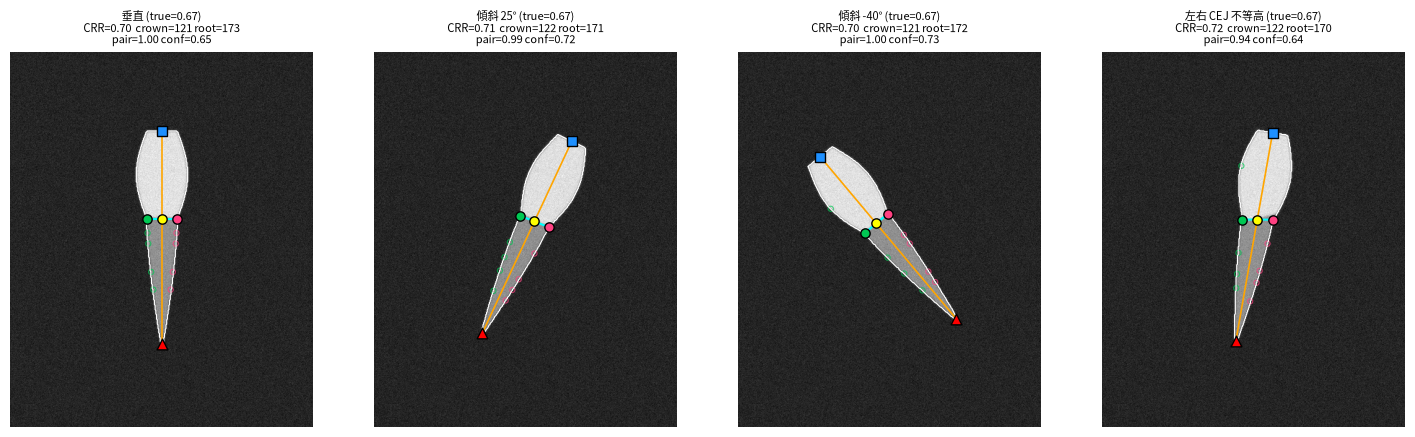

垂直           true=0.667 pred=0.702 rel.err=  5.3%  conf=0.65
傾斜 25°       true=0.667 pred=0.714 rel.err=  7.2%  conf=0.72
傾斜 -40°      true=0.667 pred=0.702 rel.err=  5.3%  conf=0.73
左右 CEJ 不等高   true=0.667 pred=0.715 rel.err=  7.3%  conf=0.64


In [51]:
def synth_tooth(crown_len=120, root_len=180, crown_w=70, angle_deg=0.0, size=(520, 420), cej_dy=0.0,
                noise=0.03, seed=SEED, crop_apex=False, crop_crown=False):
    """合成牙齒影像/mask；crown_len/root_len 為真值長度。cej_dy 讓右側 CEJ 比左側高/低（影響亮度分界）。"""
    rng = np.random.default_rng(seed)
    L = crown_len + root_len
    tt = np.linspace(0, L, 400)
    hw = np.where(tt <= crown_len,
                  crown_w / 2 * (0.6 + 0.4 * np.sin(np.pi * tt / crown_len)),
                  0.6 * crown_w / 2 * np.clip(1 - np.clip((tt - crown_len) / root_len, 0, 1) ** 1.5, 0, None))
    poly = np.vstack([np.column_stack((-hw, tt)), np.column_stack((hw, tt))[::-1]])
    th = np.radians(angle_deg)
    R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
    cx, cy = size[1] / 2, size[0] / 2
    pts = (poly - [0, L / 2]) @ R.T + [cx, cy]
    mask = np.zeros(size, np.uint8)
    cv2.fillPoly(mask, [np.round(pts).astype(np.int32)], 1)
    yy, xx = np.mgrid[0:size[0], 0:size[1]]
    rel = np.stack([xx - cx, yy - cy], -1) @ R           # 逆旋轉回牙齒座標 (s, t - L/2)
    s_, t_ = rel[..., 0], rel[..., 1] + L / 2
    crown = t_ + cej_dy * s_ / (crown_w / 2) < crown_len
    img = np.full(size, 0.15, np.float32)
    img[mask > 0] = 0.55
    img[(mask > 0) & crown] = 0.85
    img = cv2.GaussianBlur(img, (0, 0), 1.5) + rng.normal(0, noise, size).astype(np.float32)
    img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    mask = mask.astype(bool)
    if crop_apex:
        mask[:, :] &= (t_ < L * 0.8)
    if crop_crown:
        mask[:, :] &= (t_ > L * 0.2)
    return img, mask, crown_len / root_len


import copy
# 合成牙冠頂端平直，1% 百分位會削掉約 5% 軸長；這裡用 0.1% 讓端點貼近真值（真實影像維持預設 1%）。
SYN_CFG = copy.deepcopy(CFG)
SYN_CFG["axis"]["endpoint_percentile"] = 0.1
rows = []
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
cases = [("垂直", dict(angle_deg=0)), ("傾斜 25°", dict(angle_deg=25)), ("傾斜 -40°", dict(angle_deg=-40)),
         ("左右 CEJ 不等高", dict(angle_deg=10, cej_dy=15))]
for ax, (name, kw) in zip(axs, cases):
    img, m, true = synth_tooth(**kw)
    res, dbg = run_crr(img, m, SYN_CFG)
    draw_overlay(ax, img, res, dbg, f"{name} (true={true:.2f})")
    rows.append((name, true, res.crr, abs(res.crr - true) / true if np.isfinite(res.crr) else np.nan, res.confidence))
plt.show()
for r in rows:
    print(f"{r[0]:<12} true={r[1]:.3f} pred={r[2]:.3f} rel.err={r[3]*100:5.1f}%  conf={r[4]:.2f}")
assert all(r[3] < 0.10 for r in rows), "合成牙齒的 CRR 相對誤差應 < 10%"

In [52]:
# 例外情況：每一項都應回傳 warning 或低 confidence，而不是丟出錯誤或給出可信的假值
img, m, true = synth_tooth()
edge_cases = {
    "空 mask": (img, np.zeros_like(m)),
    "雜訊 mask": (img, m | (np.random.default_rng(1).random(m.shape) > 0.9995)),
    "apex 被裁切": synth_tooth(crop_apex=True)[:2],
    "crown 被裁切": synth_tooth(crop_crown=True)[:2],
    "mask 太小(10 px)": (img, np.pad(np.ones((3, 3), bool), ((100, m.shape[0] - 103), (100, m.shape[1] - 103)))),
}
for name, (im, mk) in edge_cases.items():
    r, _ = run_crr(im, mk)
    print(f"{name:<16} CRR={r.crr:.3f} conf={r.confidence:.2f} warnings={r.warnings}")

# geometry 單元檢查：CEJ 線近乎平行長軸、root=0
ax_ = ToothAxis(np.array([0., 0.]), np.array([0., 1.]), np.array([1., 0.]), 0.0, 100.0)
print(compute_crr(np.array([-5., 40.]), np.array([5., 40.]), ax_, CFG)["crr"], "(應為 40/60=0.667)")
print(compute_crr(np.array([0., 10.]), np.array([0., 60.]), ax_, CFG)["warnings"])
print(compute_crr(np.array([-5., 100.]), np.array([5., 100.]), ax_, CFG)["warnings"])
# 權重可由設定調整：改 pair_weights 會改變分數
import copy
cfg2 = copy.deepcopy(CFG); cfg2["pair_weights"]["anatomy"] = 0.0
print("pair score", run_crr(img, m)[0].cej_pair_score, "→", run_crr(img, m, cfg2)[0].cej_pair_score)
# 評估函式：以真值 CEJ 驗證
r, d = run_crr(img, m)
print(cej_line_similarity(r.left_cej.arr(), r.right_cej.arr(), r.left_cej.arr(), r.right_cej.arr() + [0, 5]))

空 mask           CRR=nan conf=0.00 warnings=['segmentation 為空']
雜訊 mask          CRR=0.778 conf=0.48 warnings=['mask 含多個連通區，只保留最大者（可能為多顆牙/雜訊）']
apex 被裁切         CRR=1.051 conf=0.64 warnings=[]
crown 被裁切        CRR=0.371 conf=0.63 warnings=[]
mask 太小(10 px)   CRR=nan conf=0.00 warnings=['處理失敗：mask 前景像素不足，無法做 PCA。']
0.6666666666666666 (應為 40/60=0.667)
['CEJ 線與長軸近乎平行，改用左右 CEJ 中點']
['root length 接近 0，CRR 不可靠']
pair score 0.9969233234476345 → 0.9
{'cosine_similarity': np.float64(0.9929882741949437), 'angle_error_deg': 6.788974574438821}


## 10. 真實影像測試

使用 `data/processed` 與 SAM pseudo-label（`coco_annotations.json`）的 test 影像 2、8、16、18，逐顆牙齒計算 CRR。沒有 CEJ ground truth，因此只能檢視 overlay；請人工確認黃點（CEJ 中點）位置。

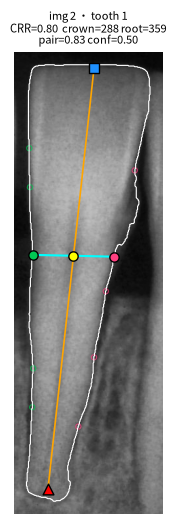

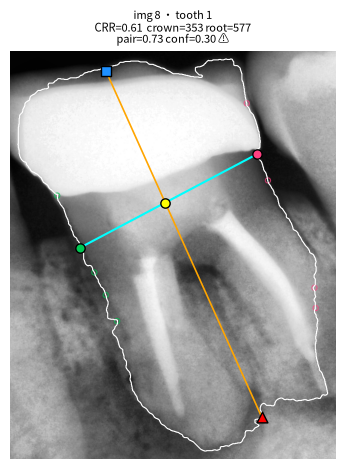

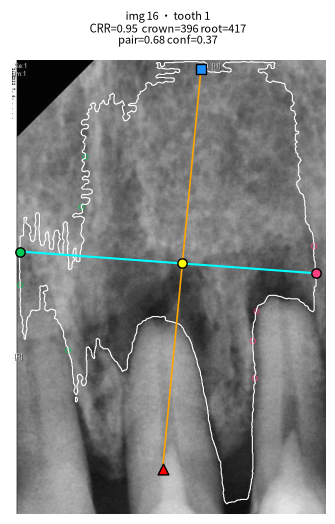

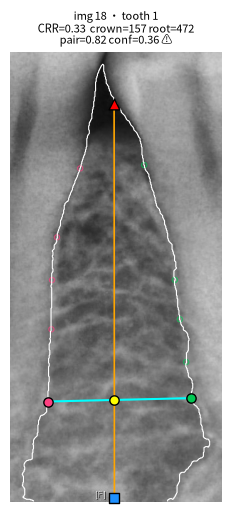

tooth          CRR   crown    root   pair   conf  warnings
2-1           0.80     288     359   0.83   0.50  
8-1           0.61     353     577   0.73   0.30  牙冠/牙根方向不明確：兩端寬度接近
16-1           0.95     396     417   0.68   0.37  
18-1           0.33     157     472   0.82   0.36  mask 接觸影像邊界（bottom），crown/root 可能不完整
JSON 已輸出到 /home/cliffyang/Program/Medical-CV/tooth_ratio/reports/models/crr_algo


In [53]:
COCO = json.loads((PROJECT_ROOT / "reports/models/sam_pseudo_labels/coco_annotations.json").read_text())
IMAGES_DIR = PROJECT_ROOT / "data/processed"
img_by_name = {i["file_name"]: i for i in COCO["images"]}
anns = {}
for a in COCO["annotations"]:
    anns.setdefault(a["image_id"], []).append(a)


def decode_segmentation(seg, h: int, w: int) -> np.ndarray:
    if isinstance(seg, dict):                               # uncompressed RLE（column-major）
        rh, rw = seg["size"]
        flat, pos, val = np.zeros(rh * rw, np.uint8), 0, 0
        for run in seg["counts"]:
            if val:
                flat[pos:pos + run] = 1
            pos, val = pos + run, 1 - val
        m = flat.reshape((rh, rw), order="F")
        return cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST).astype(bool) if (rh, rw) != (h, w) else m.astype(bool)
    m = np.zeros((h, w), np.uint8)
    for poly in seg:
        cv2.fillPoly(m, [np.round(np.array(poly).reshape(-1, 2)).astype(np.int32)], 1)
    return m.astype(bool)


def load_teeth(stem: int):
    info = img_by_name[f"{stem}.png"]
    image = cv2.cvtColor(cv2.imread(str(IMAGES_DIR / info["file_name"])), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    return image, [decode_segmentation(a["segmentation"], h, w) for a in anns.get(info["id"], [])]


STEMS = [2, 8, 16, 18]
real_results = {}
for stem in STEMS:
    image, masks = load_teeth(stem)
    n = len(masks)
    fig, axs = plt.subplots(1, max(n, 1), figsize=(4.2 * max(n, 1), 6), squeeze=False)
    for k, (ax, mk) in enumerate(zip(axs[0], masks), 1):
        ys, xs = np.nonzero(mk)
        pad = 20                                  # 只裁切顯示，座標仍用整張影像
        res, dbg = run_crr(image, mk)
        draw_overlay(ax, image, res, dbg, f"img {stem} · tooth {k}")
        if len(xs):
            ax.set_xlim(xs.min() - pad, xs.max() + pad); ax.set_ylim(ys.max() + pad, ys.min() - pad)
        real_results[(stem, k)] = (res, dbg)
    plt.show()

print(f"{'tooth':<10}{'CRR':>8}{'crown':>8}{'root':>8}{'pair':>7}{'conf':>7}  warnings")
for (stem, k), (r, _) in real_results.items():
    print(f"{stem}-{k:<8}{r.crr:8.2f}{r.crown_length_px:8.0f}{r.root_length_px:8.0f}{r.cej_pair_score:7.2f}"
          f"{r.confidence:7.2f}  {'; '.join(r.warnings)}")

for (stem, k), (r, d) in real_results.items():
    (OUTPUT_DIR / f"{stem}_tooth{k}.json").write_text(json.dumps(result_to_json(r, d), ensure_ascii=False, indent=1))
print("JSON 已輸出到", OUTPUT_DIR)

### Debug figure

切換 `DEBUG_KEY = (影像編號, 牙齒編號)`。若黃點系統性偏離牙頸，優先調整 `CFG["candidates"]["side_weights"]`、`CFG["pair_weights"]` 與 `anatomy_center`，並用醫師 CEJ 標註以 `crr_metrics` 量化。

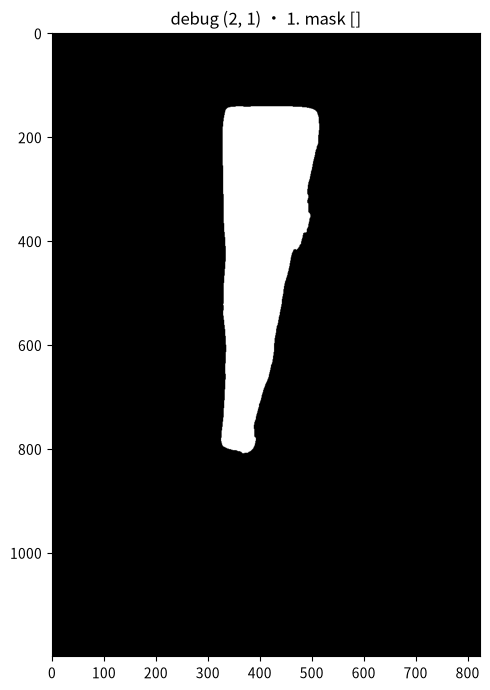

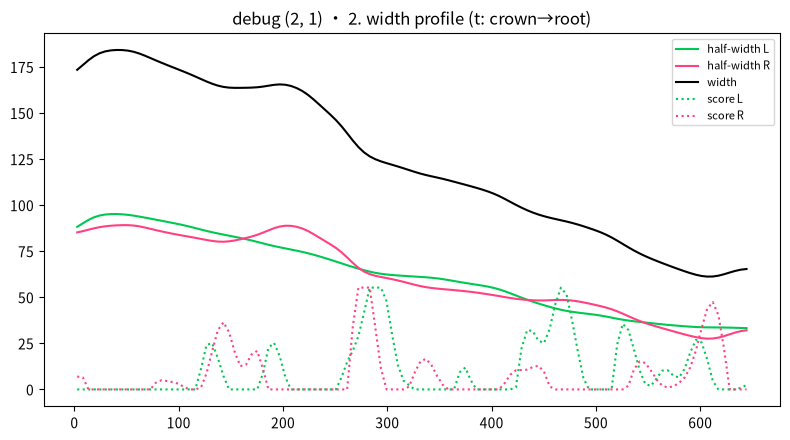

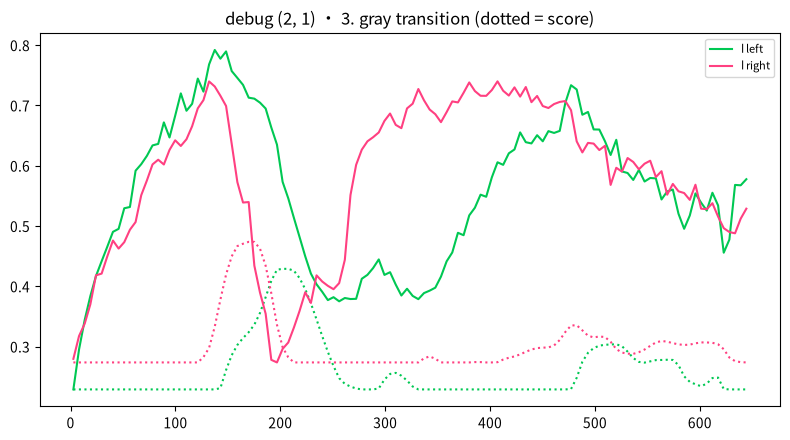

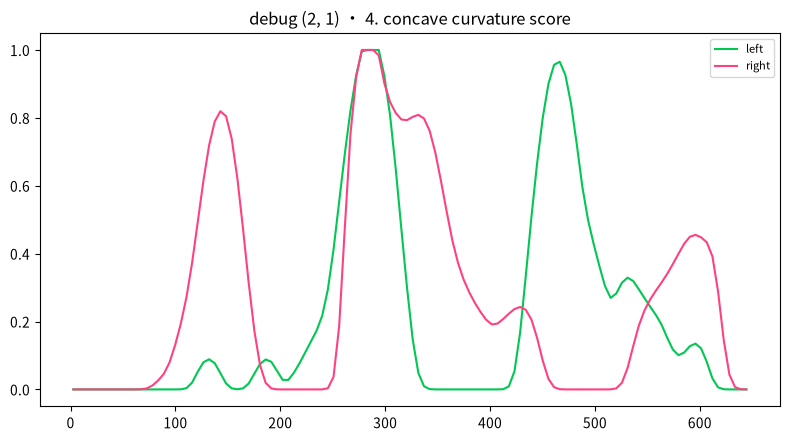

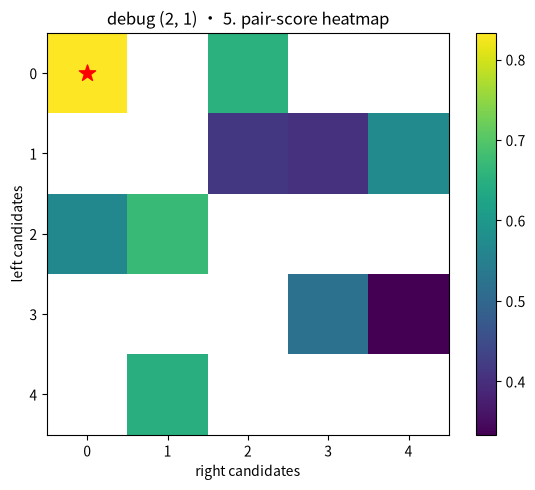

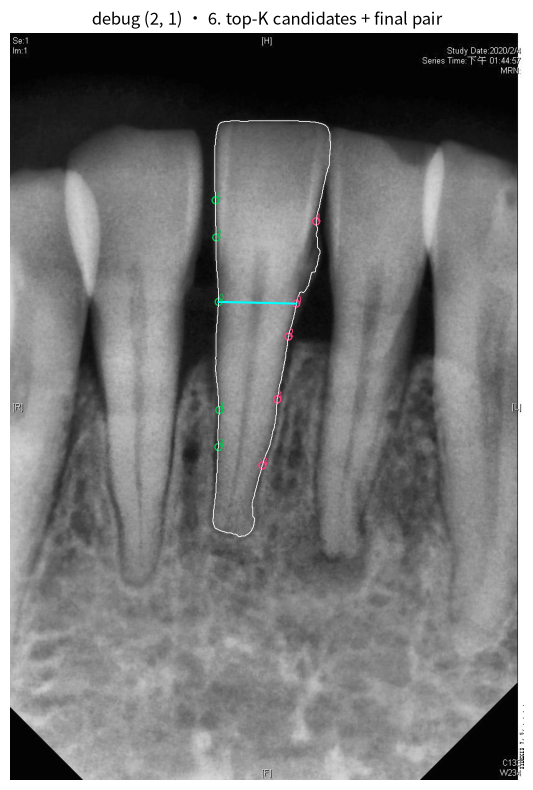

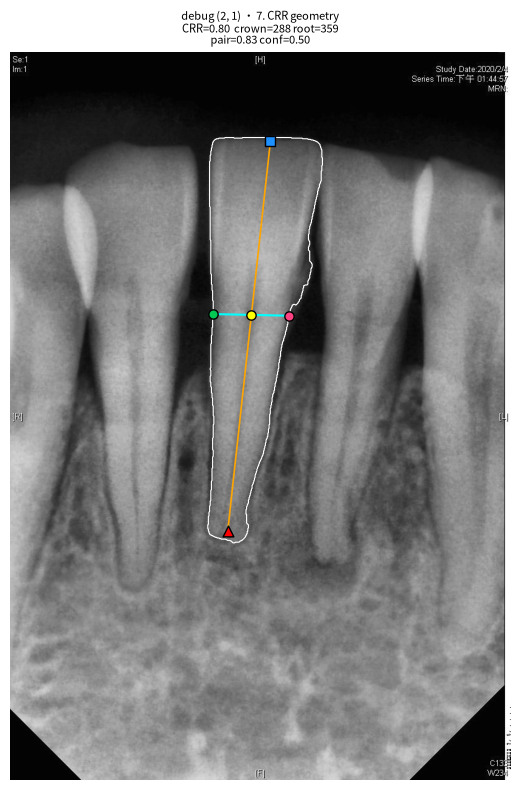

warnings:
- none


In [54]:
DEBUG_KEY = next(iter(real_results))
res, dbg = real_results[DEBUG_KEY]
if "pairs" in dbg:
    image, _ = load_teeth(DEBUG_KEY[0])
    debug_figure(image, res, dbg, f"debug {DEBUG_KEY}")
else:
    print(res.warnings)

## 11. 影像 2：以 YOLO Bounding Box 提示 SAM，量測全部牙齒

`data/yolo_tooth/labels/test/2.txt` 的人工 box → SAM ViT-B mask → 同一套 `run_crr`。需先 `uv pip install "segment-anything @ git+https://github.com/facebookresearch/segment-anything.git"`。

In [64]:
import torch
from segment_anything import SamPredictor, sam_model_registry

IDX = 18
SAM_CKPT = PROJECT_ROOT / "src/models/weights/sam_vit_b_01ec64.pth"
img_gray = cv2.imread(str(PROJECT_ROOT / f"data/yolo_tooth/images/test/{IDX}.png"), cv2.IMREAD_GRAYSCALE)
H, W = img_gray.shape
yolo = np.loadtxt(PROJECT_ROOT / f"data/yolo_tooth/labels/test/{IDX}.txt", ndmin=2)
boxes = np.array([[(xc - bw / 2) * W, (yc - bh / 2) * H, (xc + bw / 2) * W, (yc + bh / 2) * H]
                  for _, xc, yc, bw, bh in yolo], dtype=np.float32).clip(0, [W, H, W, H])
order = np.argsort(boxes[:, 0])           # 由左到右編號
boxes = boxes[order]

sam = sam_model_registry["vit_b"](checkpoint=str(SAM_CKPT)).to("cuda" if torch.cuda.is_available() else "cpu").eval()
predictor = SamPredictor(sam)
img_rgb2 = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
predictor.set_image(img_rgb2)
sam_masks = []
for b in boxes:
    ms, sc, _ = predictor.predict(box=b, multimask_output=False)
    sam_masks.append(ms[0])
print(f"image {IDX}: {len(boxes)} teeth, size {W}x{H}")

image 18: 4 teeth, size 825x1200


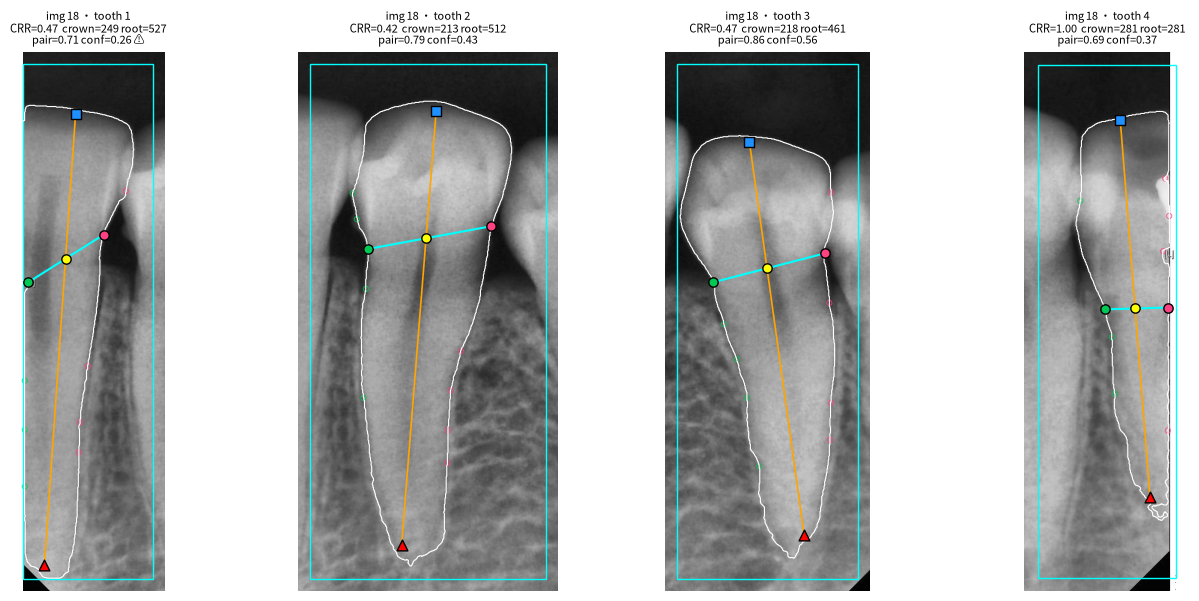

tooth      CRR   crown    root   pair   conf  warnings
1         0.47     249     527   0.71   0.26  mask 接觸影像邊界（left），crown/root 可能不完整; mask 含多個連通區，只保留最大者（可能為多顆牙/雜訊）
2         0.42     213     512   0.79   0.43  
3         0.47     218     461   0.86   0.56  
4         1.00     281     281   0.69   0.37  


In [65]:
fig, axs = plt.subplots(1, len(boxes), figsize=(4.2 * len(boxes), 7), squeeze=False)
box_results = []
for k, (ax, mk, b) in enumerate(zip(axs[0], sam_masks, boxes), 1):
    res, dbg = run_crr(img_rgb2, mk)
    draw_overlay(ax, img_rgb2, res, dbg, f"img {IDX} · tooth {k}")
    ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], fill=False, ec="cyan", lw=1))
    ax.set_xlim(b[0] - 20, b[2] + 20); ax.set_ylim(b[3] + 20, b[1] - 20)
    box_results.append((res, dbg))
plt.show()

print(f"{'tooth':<7}{'CRR':>7}{'crown':>8}{'root':>8}{'pair':>7}{'conf':>7}  warnings")
for k, (r, _) in enumerate(box_results, 1):
    print(f"{k:<7}{r.crr:7.2f}{r.crown_length_px:8.0f}{r.root_length_px:8.0f}{r.cej_pair_score:7.2f}"
          f"{r.confidence:7.2f}  {'; '.join(r.warnings)}")
for k, (r, d) in enumerate(box_results, 1):
    (OUTPUT_DIR / f"{IDX}_box_tooth{k}.json").write_text(json.dumps(result_to_json(r, d), ensure_ascii=False, indent=1))

===== tooth 1 =====
box xyxy      : [0.0, 225.0, 223.0, 1108.5]
mask area     : raw=96711 px, cleaned=97191 px
left CEJ      : (8.1, 599.9)
right CEJ     : (137.8, 518.1)
CEJ reference : (72.7, 559.2)
crown/root    : 249.1 / 526.8 px
CRR           : 0.473  (bilateral midpoint: 0.472)
pair score    : 0.712   confidence: 0.261
warnings      : ['mask 接觸影像邊界（left），crown/root 可能不完整', 'mask 含多個連通區，只保留最大者（可能為多顆牙/雜訊）']


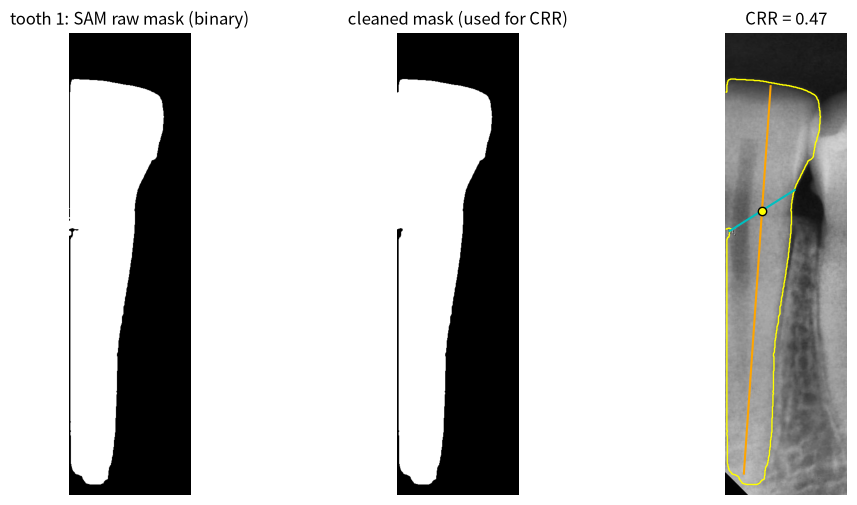

===== tooth 2 =====
box xyxy      : [100.6, 249.5, 493.5, 1107.1]
mask area     : raw=129773 px, cleaned=129779 px
left CEJ      : (196.8, 557.6)
right CEJ     : (403.0, 519.5)
CEJ reference : (294.0, 539.7)
crown/root    : 213.0 / 511.9 px
CRR           : 0.416  (bilateral midpoint: 0.412)
pair score    : 0.793   confidence: 0.430
warnings      : 無


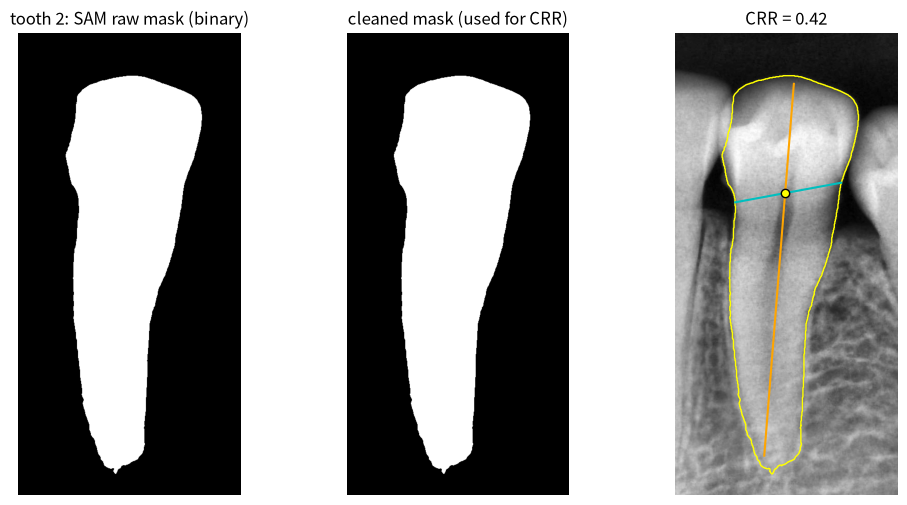

===== tooth 3 =====
box xyxy      : [414.4, 246.6, 725.2, 1128.6]
mask area     : raw=120195 px, cleaned=120199 px
left CEJ      : (477.2, 620.4)
right CEJ     : (667.3, 571.1)
CEJ reference : (568.9, 596.7)
crown/root    : 218.4 / 461.1 px
CRR           : 0.474  (bilateral midpoint: 0.472)
pair score    : 0.855   confidence: 0.561
warnings      : 無


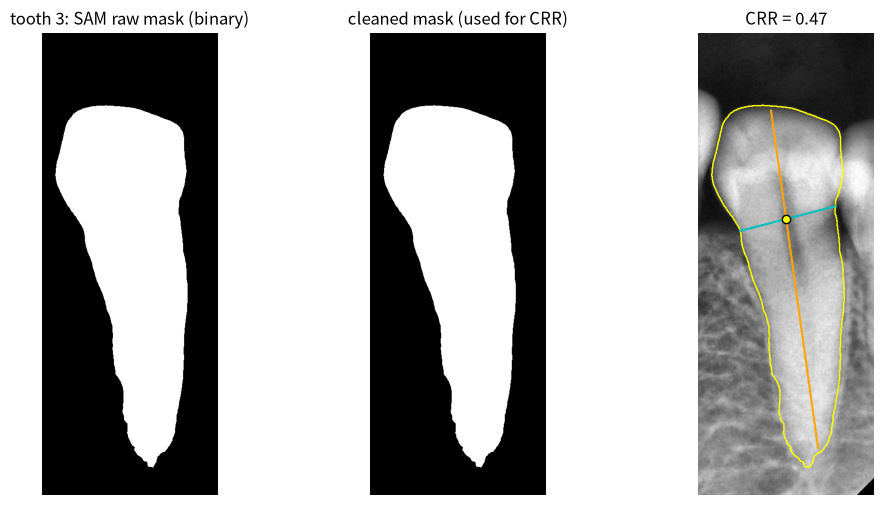

===== tooth 4 =====
box xyxy      : [618.7, 320.0, 825.0, 1082.6]
mask area     : raw=56601 px, cleaned=56613 px
left CEJ      : (719.1, 683.2)
right CEJ     : (813.1, 680.5)
CEJ reference : (763.4, 681.9)
crown/root    : 280.8 / 281.1 px
CRR           : 0.999  (bilateral midpoint: 1.000)
pair score    : 0.687   confidence: 0.372
warnings      : 無


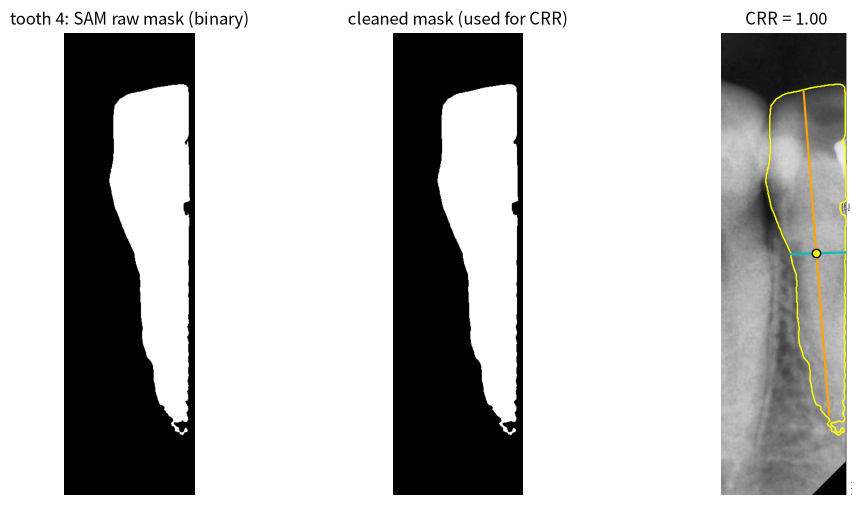

In [66]:
# 逐顆牙齒：print 量測結果，並顯示 SAM 原始 mask 與後處理後的二值圖
for k, ((res, dbg), raw, b) in enumerate(zip(box_results, sam_masks, boxes), 1):
    print(f"===== tooth {k} =====")
    print(f"box xyxy      : {np.round(b, 1).tolist()}")
    print(f"mask area     : raw={int(raw.sum())} px, cleaned={int(dbg['mask'].sum()) if 'mask' in dbg else 0} px")
    if np.isfinite(res.crr):
        print(f"left CEJ      : ({res.left_cej.x:.1f}, {res.left_cej.y:.1f})")
        print(f"right CEJ     : ({res.right_cej.x:.1f}, {res.right_cej.y:.1f})")
        print(f"CEJ reference : ({res.cej_midpoint.x:.1f}, {res.cej_midpoint.y:.1f})")
        print(f"crown/root    : {res.crown_length_px:.1f} / {res.root_length_px:.1f} px")
        print(f"CRR           : {res.crr:.3f}  (bilateral midpoint: {res.crr_bilateral_midpoint:.3f})")
    else:
        print("CRR           : nan")
    print(f"pair score    : {res.cej_pair_score:.3f}   confidence: {res.confidence:.3f}")
    print(f"warnings      : {res.warnings or '無'}")

    x1, y1, x2, y2 = (int(v) for v in b)
    pad = 20
    sl = (slice(max(y1 - pad, 0), min(y2 + pad, H)), slice(max(x1 - pad, 0), min(x2 + pad, W)))
    fig, axs = plt.subplots(1, 3, figsize=(12, 6))
    axs[0].imshow(raw[sl], cmap="gray", vmin=0, vmax=1); axs[0].set_title(f"tooth {k}: SAM raw mask (binary)")
    axs[1].imshow(dbg["mask"][sl] if "mask" in dbg else np.zeros_like(raw[sl]), cmap="gray", vmin=0, vmax=1)
    axs[1].set_title("cleaned mask (used for CRR)")
    axs[2].imshow(img_gray[sl], cmap="gray")
    axs[2].contour(dbg["mask"][sl] if "mask" in dbg else raw[sl], levels=[0.5], colors="yellow", linewidths=1)
    if np.isfinite(res.crr):
        ox, oy = sl[1].start, sl[0].start
        pts = {"left": res.left_cej, "right": res.right_cej, "crown": res.crown_endpoint, "root": res.root_endpoint}
        axs[2].plot([res.left_cej.x - ox, res.right_cej.x - ox], [res.left_cej.y - oy, res.right_cej.y - oy], "c-")
        axs[2].plot([res.crown_endpoint.x - ox, res.root_endpoint.x - ox],
                    [res.crown_endpoint.y - oy, res.root_endpoint.y - oy], color="orange")
        axs[2].scatter(res.cej_midpoint.x - ox, res.cej_midpoint.y - oy, c="yellow", edgecolors="k", zorder=5)
    axs[2].set_title(f"CRR = {res.crr:.2f}")
    for a in axs:
        a.axis("off")
    plt.show()
